# State of Data Brasil — Análise de Gênero (2021–2024)

> **Objetivo:** Investigar desigualdades de gênero no mercado de dados brasileiro.  
> **Recorte:** Gênero × Remuneração, Faixa Salarial e Senioridade.  

Hipótese "A adoção de IA está alterando a estrutura ocupacional, os impactos são diferenciados por gênero?" 

Pergunta 1 — Descritiva/inferencial (2023-2024): 

Homens e mulheres adotam IA de formas diferentes? Quem adota mais, em que tipo de uso, em que contextos?

Pergunta 2 — Estrutural (2021-2024): 

A estrutura do mercado (composição de cargos, distribuição salarial, acesso à senioridade) mudou entre os quatro anos, e essa mudança afeta homens e mulheres de forma distinta?

Na pergunta 1 o que importa é o comportamento individual por gênero — principalmente ia_usa_chatgpt_no_trabalho e ia_tipo_uso_pessoal e somente me 23/24.

A Pergunta 2 é respondida pela análise longitudinal das variáveis estruturais (Modelo A e análises inferenciais)

---
## Seção 0 — Imports e Carregamento da base de dados

In [23]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import os
import kaleido
import plotly.io as pio
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, spearmanr, norm
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from xgboost import XGBClassifier
import shap

os.makedirs('figures', exist_ok=True)
os.makedirs('data', exist_ok=True)

SEED  = 42
np.random.seed(SEED)
ALPHA = 0.05
print('OK')

OK


In [24]:
dfs_raw = {
    '2021': pd.read_csv('data/state_of_data_2021.csv', low_memory=False),
    '2022': pd.read_csv('data/state_of_data_2022.csv', low_memory=False),
    '2023': pd.read_csv('data/state_of_data_2023.csv', low_memory=False),
    '2024': pd.read_csv('data/state_of_data_2024.csv', low_memory=False),
}
for ano, df_raw in dfs_raw.items():
    print(f'{ano}: {df_raw.shape[0]:,} linhas × {df_raw.shape[1]} colunas')

2021: 2,645 linhas × 356 colunas
2022: 4,271 linhas × 353 colunas
2023: 5,293 linhas × 399 colunas
2024: 5,217 linhas × 403 colunas


### 0.1 Mapeamento de colunas por ano

In [25]:
COLUMN_MAPPING = {
    '2021': {
        'idade':            "('P1_a ', 'Idade')",
        'faixa_idade':      "('P1_a_a ', 'Faixa idade')",
        'genero':           "('P1_b ', 'Genero')",
        'estado':           "('P1_e ', 'Estado onde mora')",
        'uf':               "('P1_e_a ', 'uf onde mora')",
        'regiao':           "('P1_e_b ', 'Regiao onde mora')",
        'regiao_origem':    "('P1_g_b ', 'Regiao de origem')",
        'nivel_ensino':     "('P1_h ', 'Nivel de Ensino')",
        'area_formacao':    "('P1_i ', 'Área de Formação')",
        'situacao':         "('P2_a ', 'Qual sua situação atual de trabalho?')",
        'setor':            "('P2_b ', 'Setor')",
        'cargo':            "('P2_f ', 'Cargo Atual')",
        'gestor':           "('P2_d ', 'Gestor?')",
        'nivel':            "('P2_g ', 'Nivel')",
        'faixa_salarial':   "('P2_h ', 'Faixa salarial')",
        'tempo_area_dados': "('P2_i ', 'Quanto tempo de experiência na área de dados você tem?')",
        'tempo_area_ti':    "('P2_j ', 'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?')",
        'modalidade':       "('P2_q ', 'Atualmente qual a sua forma de trabalho?')",
    },
    '2022': {
        'idade':            "('P1_a ', 'Idade')",
        'faixa_idade':      "('P1_a_1 ', 'Faixa idade')",
        'genero':           "('P1_b ', 'Genero')",
        'estado':           "('P1_i ', 'Estado onde mora')",
        'uf':               "('P1_i_1 ', 'uf onde mora')",
        'regiao':           "('P1_i_2 ', 'Regiao onde mora')",
        'regiao_origem':    "('P1_k ', 'Regiao de origem')",
        'nivel_ensino':     "('P1_l ', 'Nivel de Ensino')",
        'area_formacao':    "('P1_m ', 'Área de Formação')",
        'situacao':         "('P2_a ', 'Qual sua situação atual de trabalho?')",
        'setor':            "('P2_b ', 'Setor')",
        'cargo':            "('P2_f ', 'Cargo Atual')",
        'gestor':           "('P2_d ', 'Gestor?')",
        'nivel':            "('P2_g ', 'Nivel')",
        'faixa_salarial':   "('P2_h ', 'Faixa salarial')",
        'tempo_area_dados': "('P2_i ', 'Quanto tempo de experiência na área de dados você tem?')",
        'tempo_area_ti':    "('P2_j ', 'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?')",
        'modalidade':       "('P2_p ', 'Atualmente qual a sua forma de trabalho?')",
    },
    '2023': {
        'idade':            "('P1_a ', 'Idade')",
        'faixa_idade':      "('P1_a_1 ', 'Faixa idade')",
        'genero':           "('P1_b ', 'Genero')",
        'estado':           "('P1_i ', 'Estado onde mora')",
        'uf':               "('P1_i_1 ', 'uf onde mora')",
        'regiao':           "('P1_i_2 ', 'Regiao onde mora')",
        'regiao_origem':    "('P1_k ', 'Regiao de origem')",
        'nivel_ensino':     "('P1_l ', 'Nivel de Ensino')",
        'area_formacao':    "('P1_m ', 'Área de Formação')",
        'situacao':         "('P2_a ', 'Qual sua situação atual de trabalho?')",
        'setor':            "('P2_b ', 'Setor')",
        'cargo':            "('P2_f ', 'Cargo Atual')",
        'gestor':           "('P2_d ', 'Gestor?')",
        'nivel':            "('P2_g ', 'Nivel')",
        'faixa_salarial':   "('P2_h ', 'Faixa salarial')",
        'tempo_area_dados': "('P2_i ', 'Quanto tempo de experiência na área de dados você tem?')",
        'tempo_area_ti':    "('P2_j ', 'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?')",
        'modalidade':       "('P2_r ', 'Atualmente qual a sua forma de trabalho?')",
    },
    '2024': {
        'idade':            '1.a_idade',
        'faixa_idade':      '1.a.1_faixa_idade',
        'genero':           '1.b_genero',
        'estado':           '1.i_estado_onde_mora',
        'uf':               '1.i.1_uf_onde_mora',
        'regiao':           '1.i.2_regiao_onde_mora',
        'regiao_origem':    '1.k.2_regiao_de_origem',
        'nivel_ensino':     '1.l_nivel_de_ensino',
        'area_formacao':    '1.m_área_de_formação',
        'situacao':         '2.a_situação_de_trabalho',
        'setor':            '2.b_setor',
        'cargo':            '2.f_cargo_atual',
        'gestor':           '2.d_atua_como_gestor',
        'nivel':            '2.g_nivel',
        'faixa_salarial':   '2.h_faixa_salarial',
        'tempo_area_dados': '2.i_tempo_de_experiencia_em_dados',
        'tempo_area_ti':    '2.j_tempo_de_experiencia_em_ti',
        'modalidade':       '2.r_modelo_de_trabalho_atual',
    }
}

IA_COLS = {
    '2023': {
        'ia_prioridade_empresa':      "('P3_e ', 'AI Generativa é uma prioridade em sua empresa?')",
        'ia_tipos_uso_gestao':        "('P3_f ', 'Tipos de uso de AI Generativa e LLMs na empresa')",
        'ia_motivos_nao_usar':        "('P3_g ', 'Motivos que levam a empresa a não usar AI Genrativa e LLMs')",
        'ia_tipo_uso_pessoal':        "('P4_l ', 'Qual o tipo de uso de AI Generativa e LLMs na empresa')",
        'ia_usa_chatgpt_no_trabalho': "('P4_m ', 'Utiliza ChatGPT ou LLMs no trabalho?')",
    },
    '2024': {
        'ia_prioridade_empresa':      '3.e_ai_generativa_e_llm_é_uma_prioridade?',
        'ia_tipos_uso_gestao':        '3.f_tipo_de_uso_de_ai_generativa_e_llm_na_empresa',
        'ia_motivos_nao_usar':        '3.g_motivos_para_não_usar_ai_generativa_e_llm',
        'ia_tipo_uso_pessoal':        '4.l_tipo_de_uso_de_ai_generativa_e_llm_na_empresa',
        'ia_usa_chatgpt_no_trabalho': '4.m_usa_chatgpt_ou_copilot_no_trabalho?',
    },
}

IA_FEATS_ALL = [
    'ia_prioridade_empresa',
    'ia_tipos_uso_gestao',
    'ia_motivos_nao_usar',
    'ia_tipo_uso_pessoal',
    'ia_usa_chatgpt_no_trabalho'
]

### 0.2 Mapeamentos ordinais e de categorias

In [26]:
FAIXA_SALARIAL_MAP = {
    'de R$ 1.001/mês a R$ 2.000/mês':   'R$1k-2k',
    'de R$ 2.001/mês a R$ 3.000/mês':   'R$2k-3k',
    'de R$ 2.001/mês a R$ 3000/mês':    'R$2k-3k',
    'de R$ 3.001/mês a R$ 4.000/mês':   'R$3k-4k',
    'de R$ 4.001/mês a R$ 6.000/mês':   'R$4k-6k',
    'de R$ 6.001/mês a R$ 8.000/mês':   'R$6k-8k',
    'de R$ 8.001/mês a R$ 12.000/mês':  'R$8k-12k',
    'de R$ 12.001/mês a R$ 16.000/mês': 'R$12k-16k',
    'de R$ 16.001/mês a R$ 20.000/mês': 'R$16k-20k',
    'de R$ 20.001/mês a R$ 25.000/mês': 'R$20k-25k',
    'de R$ 25.001/mês a R$ 30.000/mês': 'R$25k-30k',
    'de R$ 30.001/mês a R$ 40.000/mês': 'R$30k-40k',
    'Acima de R$ 40.001/mês':           'R$40k+',
}
FAIXA_SALARIAL_ORDEM = [
    'R$1k-2k', 'R$2k-3k', 'R$3k-4k', 'R$4k-6k', 'R$6k-8k',
    'R$8k-12k', 'R$12k-16k', 'R$16k-20k', 'R$20k-25k',
    'R$25k-30k', 'R$30k-40k', 'R$40k+',
]
NIVEL_ENSINO_ORDEM = [
    'Não tenho graduação formal', 'Estudante de Graduação',
    'Graduação/Bacharelado', 'Especialização Lato Sensu',
    'Mestrado', 'Doutorado ou Phd',
]
#NIVEL_SENIORIDADE_ORDEM = ['Júnior', 'Pleno', 'Sênior', 'Gestor']
NIVEL_SENIORIDADE_ORDEM = ['Júnior', 'Pleno', 'Sênior']  # leakage
NIVEL_SENIORIDADE_EDA    = ['Júnior', 'Pleno', 'Sênior', 'Gestor']  # EDA

CARGO_MAP = {
    'Analista de Dados/Data Analyst':                    'Analista de Dados',
    'Analista de BI/BI Analyst':                         'Analista de Dados',
    'Analista de BI/BI Analyst/Analytics Engineer':      'Analista de Dados',
    'Analista de Negócios/Business Analyst':             'Analista de Dados',
    'Analista de Inteligência de Mercado/Market Intelligence': 'Analista de Dados',
    'Analista de Marketing':                             'Analista de Dados',
    'Analista Administrativo':                           'Analista de Dados',
    'Estatístico':                                       'Analista de Dados',
    'Economista':                                        'Analista de Dados',
    'Engenheiro de Dados/Arquiteto de Dados/Data Engineer/Data Architect': 'Engenheiro de Dados',
    'Engenheiro de Dados/Data Engineer':                 'Engenheiro de Dados',
    'Analytics Engineer':                                'Engenheiro de Dados',
    'Arquiteto de Dados':                                'Engenheiro de Dados',
    'Arquiteto de dados':                                'Engenheiro de Dados',
    'DBA/Administrador de Banco de Dados':               'Engenheiro de Dados',
    'Engenheiro de Dados/Data Engineer/Data Architect':  'Engenheiro de Dados',
    'Arquiteto de Dados/Data Architect':                 'Engenheiro de Dados',
    'Cientista de Dados/Data Scientist':                 'Cientista de Dados',
    'Engenheiro de Machine Learning/ML Engineer':        'Cientista de Dados',
    'Engenheiro de Machine Learning/ML Engineer/AI Engineer': 'Cientista de Dados',
    'Professor':                                         'Professor/Pesquisador',
    'Data Product Manager/ Product Manager (PM/APM/DPM/GPM/PO)': 'Product Manager',
    'Product Manager/ Product Owner (PM/APM/DPM/GPM/PO)': 'Product Manager',
    'Desenvolvedor/ Engenheiro de Software/ Analista de Sistemas': 'Desenvolvedor',
    'Desenvolvedor ou Engenheiro de Software':           'Desenvolvedor',
    'Analista de Sistemas/Analista de TI':               'Desenvolvedor',
    'Analista de Suporte/Analista Técnico':              'Desenvolvedor',
    'Suporte Técnico':                                   'Desenvolvedor',
    'Técnico':                                           'Desenvolvedor',
    'Outra Opção':                                       'Outro',
    'Outras Engenharias (não inclui dev)':               'Outro',
}
AREA_FORMACAO_MAP = {
    'Computação / Engenharia de Software / Sistemas de Informação/ TI': 'Computação / TI',
    'Outras Engenharias': 'Engenharia (outras)',
    'Outras Engenharias (não incluir engenharia de software ou TI)': 'Engenharia (outras)',
    'Economia/ Administração / Contabilidade / Finanças/ Negócios': 'Economia / Adm / Finanças',
    'Economia/ Administração / Contabilidade / Finanças': 'Economia / Adm / Finanças',
    'Estatística/ Matemática / Matemática Computacional/ Ciências Atuariais': 'Estatística / Matemática',
    'Estatística/ Matemática / Matemática Computacional': 'Estatística / Matemática',
    'Ciências Biológicas/ Farmácia/ Medicina/ Área da Saúde': 'Ciências da Saúde',
    'Ciências Biológicas/Farmácia/Medicina/Área da Saúde': 'Ciências da Saúde',
    'Marketing / Publicidade / Comunicação / Jornalismo': 'Marketing / Comunicação',
    'Marketing / Publicidade / Comunicação / Jornalismo / Ciências Sociais': 'Marketing / Comunicação',
    'Outra opção': 'Outras',
}
SITUACAO_MAP = {
    'Vivo no Brasil e trabalho remoto para empresa de fora do Brasil':      'Remoto p/ exterior',
    'Vivo no Brasil e trabalho remoto para empresa de fora do Brasil (PJ)': 'Remoto p/ exterior',
    'Desempregado, buscando recolocação':                                   'Desempregado',
    'Desempregado e não estou buscando recolocação':                        'Desempregado',
    'Somente Estudante (graduação)':                                        'Somente Estudante',
    'Somente Estudante (pós-graduação)':                                    'Somente Estudante',
    'Prefiro não informar':                                                  None,
}

REGIAO_MAP = {
    'Centro_Oeste': 'Centro-Oeste', 'Centro Oeste': 'Centro-Oeste',
    'centro-oeste': 'Centro-Oeste', 'Centro-oeste': 'Centro-Oeste',
    'nordeste': 'Nordeste', 'norte': 'Norte',
    'sudeste': 'Sudeste',  'sul':    'Sul',
    'Exterior': None, 'Prefiro não informar': None,
}

MODALIDADE_RENAME = {
    'Modelo 100% presencial': 'Presencial',
    'Modelo 100% remoto': 'Remoto',
    'Modelo híbrido flexível (o funcionário tem liberdade para escolher quando estar no escritório presencialmente)': 'Híbrido flexível',
    'Modelo híbrido com dias fixos de trabalho presencial': 'Híbrido fixo',
}

ANOS     = ['2021', '2022', '2023', '2024']
REGIOES = ['Sudeste', 'Sul', 'Nordeste', 'Centro-Oeste', 'Norte']

CORES_GENERO = {'Masculino': '#517493', 'Feminino': '#64313E'}
CORES_REGIAO = {
    'Sudeste':      '#2563EB',
    'Sul':          '#16A34A',
    'Nordeste':     '#EA580C',
    'Centro-Oeste': '#9333EA',
    'Norte':        '#CA8A04',
}
TEMPLATE = 'plotly_white'

In [27]:
# ia_usa_chatgpt_no_trabalho
_NAO_USA        = 'Não utilizo nenhum tipo de solução de IA Generativa'
_USA_GRATUITA   = 'Utilizo apenas soluções gratuitas'
_USA_PAGA_PROP  = 'pago do meu próprio bolso'
_USA_PAGA_EMP   = 'a empresa em que trabalho paga'
_USA_COPILOT    = 'Copilot'
 
# ia_prioridade_empresa — strings que indicam alta prioridade
_PRIORIDADE_ALTA = [
    'Sim, é nossa principal prioridade',
    'Sim, está entre nossas principais prioridades',
]
 
# ia_tipo_uso_pessoal / ia_tipos_uso_gestao — uso difuso/bottom-up
_ORG_COLABORADORES = 'Colaboradores utilizando soluções baseadas em AI Generativa'

def engenharia_ia(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adiciona 7 features binárias de IA ao dataframe.
 
    Parâmetros
    ----------
    df : DataFrame com as colunas brutas de IA já mapeadas pelo pipeline
         (ia_usa_chatgpt_no_trabalho, ia_prioridade_empresa,
          ia_tipo_uso_pessoal, ia_tipos_uso_gestao).
 
    Retorna
    -------
    df com as novas colunas; colunas brutas de IA são mantidas.
    """
    df = df.copy()
 
    # --- 1. Bloco de uso individual (ia_usa_chatgpt_no_trabalho) -------------
    # Multi-label: opções separadas por '., ' ou ', '
    # Cada feature detecta a presença da substring atômica correspondente.
 
    col = 'ia_usa_chatgpt_no_trabalho'
    s   = df[col].fillna('')   # NaN → string vazia → todas as flags ficam 0
 
    df['ia_nao_usa']       = s.str.contains(_NAO_USA,       na=False).astype('Int8')
    df['ia_usa_gratuita']  = s.str.contains(_USA_GRATUITA,  na=False).astype('Int8')
    df['ia_usa_paga_prop'] = s.str.contains(_USA_PAGA_PROP, na=False).astype('Int8')
    df['ia_usa_paga_emp']  = s.str.contains(_USA_PAGA_EMP,  na=False).astype('Int8')
    df['ia_usa_copilot']   = s.str.contains(_USA_COPILOT,   na=False).astype('Int8')
 
    # Respondentes sem dados de IA (2021/2022) → NaN para manter distinção
    # entre "não usa" (resposta válida) e "pergunta não existia" (ausência)
    sem_dados = df[col].isna()
    for c in ['ia_nao_usa', 'ia_usa_gratuita', 'ia_usa_paga_prop',
              'ia_usa_paga_emp', 'ia_usa_copilot']:
        df.loc[sem_dados, c] = pd.NA
 
    # --- 2. Prioridade organizacional (ia_prioridade_empresa) ----------------
    col_pri = 'ia_prioridade_empresa'
    if col_pri in df.columns:
        s_pri = df[col_pri].fillna('')
        df['ia_empresa_prioridade_alta'] = s_pri.apply(
            lambda x: 1 if any(p in x for p in _PRIORIDADE_ALTA) else
                      (pd.NA if x == '' else 0)
        ).astype('Int8')
    else:
        df['ia_empresa_prioridade_alta'] = pd.NA
 
    # --- 3. Uso difuso/bottom-up na empresa ----------------------------------
    # Une ia_tipo_uso_pessoal (2023) e ia_tipos_uso_gestao (2024) — mesma pergunta
    col_tp = 'ia_tipo_uso_pessoal'
    col_tg = 'ia_tipos_uso_gestao'
 
    s_org = pd.Series('', index=df.index)
    if col_tp in df.columns:
        s_org = s_org + df[col_tp].fillna('')
    if col_tg in df.columns:
        s_org = s_org + df[col_tg].fillna('')
 
    sem_org = (
        (df.get(col_tp, pd.Series(pd.NA, index=df.index)).isna()) &
        (df.get(col_tg, pd.Series(pd.NA, index=df.index)).isna())
    )
    df['ia_org_uso_difuso'] = s_org.str.contains(_ORG_COLABORADORES, na=False).astype('Int8')
    df.loc[sem_org, 'ia_org_uso_difuso'] = pd.NA
 
    return df

In [28]:
IA_FEATURES_MODELO_B = [
    'ia_nao_usa',
    'ia_usa_gratuita',
    'ia_usa_paga_prop',
    'ia_usa_paga_emp',
    'ia_usa_copilot',
    'ia_empresa_prioridade_alta',
    'ia_org_uso_difuso',
]
 
# Labels legíveis para SHAP / gráficos
IA_FEATURE_LABELS = {
    'ia_nao_usa':                  'Não usa IA',
    'ia_usa_gratuita':             'Usa IA gratuita',
    'ia_usa_paga_prop':            'Usa IA paga (bolso próprio)',
    'ia_usa_paga_emp':             'Usa IA paga (empresa paga)',
    'ia_usa_copilot':              'Usa Copilot',
    'ia_empresa_prioridade_alta':  'IA é prioridade alta na empresa',
    'ia_org_uso_difuso':           'Uso difuso/bottom-up na organização',
}

---
## Seção 1 — Pipeline de pré-processamento

In [29]:
def build_year_dataframe(df_raw: pd.DataFrame, year: str) -> pd.DataFrame:

    # COLUNAS BASE
    
    base_map = COLUMN_MAPPING[year]

    cols_base = {
        old: new
        for new, old in base_map.items()
        if old in df_raw.columns
    }

    df = df_raw[list(cols_base.keys())].rename(columns=cols_base).copy()

    
    # COLUNAS DE IA (2023/2024)
    
    if year in IA_COLS:

        ia_map = IA_COLS[year]

        cols_ia = {
            old: new
            for new, old in ia_map.items()
            if old in df_raw.columns
        }
        
        ia_df = (df_raw[list(cols_ia.keys())].rename(columns=cols_ia))

        df = pd.concat([df, ia_df], axis=1)

    # ANO
   
    df.insert(0, 'ano_pesquisa', year)

    return df
    

In [30]:
def preprocess(df: pd.DataFrame) -> pd.DataFrame:

    
    # GÊNERO
    
    df = df[df['genero'].isin(['Masculino', 'Feminino'])].copy()

    # NÍVEL DE ENSINO
    
    df['nivel_ensino'] = (
        df['nivel_ensino']
        .replace({
            'Pós-graduação': 'Especialização Lato Sensu',
            'Prefiro não informar': np.nan
        })
    )

    df['nivel_ensino'] = pd.Categorical(
        df['nivel_ensino'],
        categories=NIVEL_ENSINO_ORDEM,
        ordered=True
    )

    # FAIXA SALARIAL
    
    df['faixa_salarial'] = (
        df['faixa_salarial']
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
        .replace(FAIXA_SALARIAL_MAP)
    )

    df['faixa_salarial'] = pd.Categorical(
        df['faixa_salarial'],
        categories=FAIXA_SALARIAL_ORDEM,
        ordered=True
    )

    # CARGO / ÁREA / REGIÃO
    
    df['cargo'] = df['cargo'].replace(CARGO_MAP)

    df['area_formacao'] = (
        df['area_formacao']
        .replace(AREA_FORMACAO_MAP)
    )

    df['regiao'] = (
        df['regiao']
        .replace(REGIAO_MAP)
    )

    # MODALIDADE
    df['modalidade'] = df['modalidade'].map(MODALIDADE_RENAME).fillna(df['modalidade'])

    # SENIORIDADE
    
    df['nivel'] = pd.Categorical(
        df['nivel'].where(
            df['nivel'].isin(NIVEL_SENIORIDADE_ORDEM)
        ),
        categories=NIVEL_SENIORIDADE_ORDEM,
        ordered=True
    )

    # GESTOR (0/1)
    # NaN é mantido: representa não-resposta, não "não é gestor".
    # O fillna(0) anterior inflava a classe 0 silenciosamente.
    df['gestor'] = (
        df['gestor']
        .replace({
            'Sim': 1,
            'Não': 0,
            'sim': 1,
            'não': 0
        })
        .pipe(pd.to_numeric, errors='coerce')  # valores inesperados → NaN
    )


    # SITUAÇÃO
    
    df['situacao'] = (
        df['situacao']
        .replace(SITUACAO_MAP)
    )

    df = df[df['situacao'].notna()]

    return df.reset_index(drop=True)

In [31]:
def run_pipeline(dfs_raw: dict) -> pd.DataFrame:
    """
    Constrói o dataset unificado a partir dos CSVs brutos.
    Etapas: renomear colunas → concatenar anos → limpar.
    """
    frames = []
    for year in ANOS:
        print(f'  {year}...')
        frames.append(build_year_dataframe(dfs_raw[year], year))

    df = pd.concat(frames, ignore_index=True)
    df = preprocess(df)
    df = engenharia_ia(df)
    return df


In [32]:
df = run_pipeline(dfs_raw)

  2021...
  2022...
  2023...
  2024...


In [33]:
# SPLIT TREINO / TESTE

df_train = df[df['ano_pesquisa'] != '2024'].copy()

df_test = df[df['ano_pesquisa'] == '2024'].copy()

# SAVE

df.to_parquet(
    'data/df_full.parquet',
    index=False
)

df_train.to_parquet(
    'data/df_train.parquet',
    index=False
)

df_test.to_parquet(
    'data/df_test.parquet',
    index=False
)

# SHAPES

print(f' df_full: {df.shape}')
print(f' treino: {df_train.shape}')
print(f' teste: {df_test.shape}')

# -----------------------------
# COBERTURA IA
# -----------------------------
print('\nCobertura IA:')

for nome, subset in [
    ('Treino', df_train),
    ('Teste', df_test)
]:

    cobertura = (
        subset[IA_FEATS_ALL]
        .notna()
        .any(axis=1)
        .mean() * 100
    )

    print(f'{nome}: {cobertura:.1f}%')

 df_full: (17295, 31)
 treino: (12117, 31)
 teste: (5178, 31)

Cobertura IA:
Treino: 38.3%
Teste: 89.5%


---
## Seção 2 — Análise Exploratória de Dados EDA

Cada visualização responde uma pergunta diferente, todas longitudinais por ano sem agregação e sem redundância. 

- 2.1 Representatividade feminina ao longo dos anos
- 2.2 Senioridade por gênero
- 2.3 Distribuição de cargos por gênero
- 2.4 Diferença salarial entre gêneros
- 2.5 Escolaridade por gênero
- 2.6 Área de formação por gênero
- 2.7 Distribuição de Experiência na Área de Dados por Gênero
- 2.8 Modalidade de trabalho por gênero
- 2.9 Adoção de IA por gênero
- 2.10 Análise regional da participação feminina


### 2.0 Config

In [34]:
def fmt(fig, title, height=450, **kw):
    fig.update_layout(
        title=title,
        template=TEMPLATE,
        height=height,
        legend=dict(orientation='h', y=1.02, x=1, xanchor='right'),
        **kw,
    )
    return fig
 
 
def dedup_legend(fig):
    seen = set()
    for t in fig.data:
        t.showlegend = t.name not in seen
        seen.add(t.name)
    return fig
 
 
def subplots_pct_fem(df, col, order, title, height=420):
    """
    Subplots 1×4 (um por ano): % feminino por categoria.
    - % do gênero feminino dentro de cada categoria sobreposto na barra (cor branca, bold)
    - n total da categoria exibido fora da barra
    - range do eixo X calculado dinamicamente (máx + margem de 15 pp)
    """
    # calcula range dinâmico
    tab_all = pd.crosstab(df[col], df['genero']).reindex(order).fillna(0)
    n_all   = tab_all.sum(axis=1)
    pct_max = (tab_all.get('Feminino', 0) / n_all.replace(0, np.nan) * 100).max()
    x_max   = min(100, np.ceil((pct_max + 15) / 10) * 10)
 
    fig = make_subplots(1, 4, subplot_titles=ANOS, shared_yaxes=True)
 
    for i, ano in enumerate(ANOS, 1):
        sub = df[df['ano_pesquisa'] == ano]
        tab = pd.crosstab(sub[col], sub['genero']).reindex(order).fillna(0)
        n   = tab.sum(axis=1)
        pct = tab.get('Feminino', pd.Series(0, index=tab.index)) / n.replace(0, np.nan) * 100
 
        # texto dentro da barra: % (branco, negrito visual via tamanho)
        text_inside = [
            f'<b>{v:.0f}%</b>' if not np.isnan(v) else ''
            for v in pct
        ]
        # texto fora da barra: n total
        text_outside = [f'n={int(ni)}' for ni in n]
 
        # barra principal com % dentro
        fig.add_trace(go.Bar(
            y=pct.index,
            x=pct.values,
            orientation='h',
            marker_color=CORES_GENERO['Feminino'],
            text=text_inside,
            textposition='inside',
            textfont=dict(color='white', size=11),
            showlegend=False,
            customdata=n.values,
            hovertemplate='%{y}: %{x:.1f}% feminino (n=%{customdata})<extra></extra>',
        ), row=1, col=i)
 
        # marcadores invisíveis para exibir n fora da barra
        fig.add_trace(go.Scatter(
            y=pct.index,
            x=pct.values,
            mode='text',
            text=text_outside,
            textposition='middle right',
            textfont=dict(size=9, color='gray'),
            showlegend=False,
        ), row=1, col=i)
 
        fig.update_xaxes(range=[0, x_max], ticksuffix='%', row=1, col=i)
 
    return fmt(fig, title, height=height)
 
 
def subplots_piramide(df, col, order, title, height=420):
    """
    Subplots 1×4: pirâmide bilateral — % dentro de cada gênero por categoria.
    Feminino à esquerda (negativo), Masculino à direita.
    Ordem da legenda: Feminino primeiro.
    """
    fig = make_subplots(1, 4, subplot_titles=ANOS, shared_yaxes=True)
 
    # Feminino sempre primeiro para fixar ordem da legenda
    for genero in ['Feminino', 'Masculino']:
        for i, ano in enumerate(ANOS, 1):
            sub = df[df['ano_pesquisa'] == ano]
            tab = pd.crosstab(sub[col], sub['genero']).reindex(order).fillna(0)
            pct = tab.div(tab.sum(), axis=1) * 100

            vals = pct.get(genero, pd.Series(0, index=pct.index))
            x    = -vals if genero == 'Feminino' else vals

            fig.add_trace(go.Bar(
                y=pct.index,
                x=x,
                orientation='h',
                name=genero,
                legendgroup=genero,
                marker_color=CORES_GENERO[genero],
                text=[f'{v:.0f}%' for v in vals],
                textposition='auto',
                textfont=dict(color='white', size=10),
            ), row=1, col=i)

    # Linha central e eixos aplicados uma vez por subplot, fora do loop de gênero
    for i in range(1, len(ANOS) + 1):
        fig.add_shape(
            type='line', x0=0, x1=0,
            y0=-0.5, y1=len(order) - 0.5,
            line=dict(color='black', dash='dot', width=1),
            row=1, col=i,
        )
        fig.update_xaxes(
            range=[-60, 60],
            tickvals=[-40, -20, 0, 20, 40],
            ticktext=['40%', '20%', '0', '20%', '40%'],
            row=1, col=i,
        )

    dedup_legend(fig)
    return fmt(fig, title, height=height, barmode='relative')

### 2.1 — Representatividade feminina ao longo dos anos



In [35]:
tab = pd.crosstab(df['ano_pesquisa'], df['genero']).reindex(ANOS)
pct_fem = tab['Feminino'].div(tab.sum(axis=1)).mul(100)
 
fig = go.Figure(go.Scatter(
    x=ANOS,
    y=pct_fem,
    mode='lines+markers+text',
    text=[
        f'<b>{v:.1f}%</b><br><sup>n={int(n)}</sup>'
        for v, n in zip(pct_fem, tab.sum(axis=1))
    ],
    textposition='top center',
    line=dict(color=CORES_GENERO['Feminino'], width=3),
    marker=dict(size=10),
))
 
fig = fmt(fig, 'Representatividade Feminina por Ano (2021–2024)', height=360)
fig.update_yaxes(title='% Feminino', ticksuffix='%', range=[0, 40])
fig.show()


### 2.2 — Senioridade por gênero



In [36]:
fig = subplots_piramide(
    df, 'nivel', NIVEL_SENIORIDADE_EDA,
    'Senioridade por Gênero (2021–2024)',
)
fig.show()


### 2.3 — Cargo por gênero

In [37]:
CARGO_ORDEM = [
    'Analista de Dados',
    'Cientista de Dados',
    'Engenheiro de Dados',
    'Desenvolvedor',
    'Product Manager',
    'Professor/Pesquisador',
    'Outro',
]
 
fig = subplots_pct_fem(
    df, 'cargo', CARGO_ORDEM,
    '% Feminino por Cargo (2021–2024)',
    height=440,
)
fig.show()



### 2.4 — Distribuição salarial por gênero

In [38]:
fig = subplots_piramide(
    df, 'faixa_salarial', FAIXA_SALARIAL_ORDEM,
    'Distribuição Salarial por Gênero — % dentro de cada gênero (2021–2024)',
    height=560,
)
fig.show()


### 2.5 — Escolaridade por gênero

In [39]:
fig = subplots_pct_fem(
    df, 'nivel_ensino', NIVEL_ENSINO_ORDEM,
    '% Feminino por Nível de Ensino (2021–2024)',
    height=440,
)
fig.show()



In [40]:
# Distribuição de escolaridade dentro de cada gênero (% por nível)
tab_ens = pd.crosstab(df['nivel_ensino'], df['genero'])
tab_ens_pct = tab_ens.div(tab_ens.sum(axis=0), axis=1) * 100
tab_ens_pct = tab_ens_pct.reindex(NIVEL_ENSINO_ORDEM)

fig = go.Figure()
for genero in ['Feminino', 'Masculino']:
    fig.add_trace(go.Bar(
        name=genero,
        x=tab_ens_pct.index,
        y=tab_ens_pct[genero],
        marker_color=CORES_GENERO[genero],
        text=[f"{v:.1f}%" for v in tab_ens_pct[genero]],
        textposition='outside',
    ))
fig = fmt(
    fig,
    'Distribuição de Escolaridade por Gênero (% dentro de cada gênero)',
    height=420,
    barmode='group',
)
fig.update_yaxes(title='%', ticksuffix='%')
fig.show()


### 2.6 — Área de formação por gênero

In [41]:
AREA_ORDEM = [
    'Computação / TI',
    'Engenharia (outras)',
    'Estatística / Matemática',
    'Economia / Adm / Finanças',
    'Ciências da Saúde',
    'Marketing / Comunicação',
    'Outras',
]
 
fig = subplots_pct_fem(
    df, 'area_formacao', AREA_ORDEM,
    '% Feminino por Área de Formação (2021–2024)',
    height=440,
)
fig.show()


### 2.7 — Experiência na área de dados por gênero

In [42]:
TEMPO_ORDEM = [
    'Menos de 1 ano',
    'de 1 a 2 anos',
    'de 2 a 3 anos',
    'de 3 a 4 anos',
    'de 4 a 5 anos',
    'de 5 a 6 anos',
    'de 6 a 7 anos',
    'de 7 a 10 anos',
    'Mais de 10 anos',
]
 
tempo_valido = [t for t in TEMPO_ORDEM if t in df['tempo_area_dados'].dropna().unique()]
 
fig = subplots_pct_fem(
    df[df['tempo_area_dados'].isin(tempo_valido)],
    'tempo_area_dados',
    tempo_valido,
    '% Feminino por Tempo de Experiência em Dados (2021–2024)',
    height=440,
)
fig.show()


### 2.8 — Modalidade de trabalho por gênero

In [43]:
MODALIDADE_ORDEM = ['Remoto', 'Híbrido flexível', 'Híbrido fixo', 'Presencial']

fig = subplots_piramide(
    df[df['modalidade'].notna()], 'modalidade', MODALIDADE_ORDEM,
    '% Feminino por Modalidade de Trabalho (2021–2024)',
    height=400,
)
fig.show()

### 2.9 — Adoção de IA generativa por gênero 

In [44]:
ANOS_IA = ['2023', '2024']
df_ia = df[df['ano_pesquisa'].isin(ANOS_IA)].copy()

df_ia['usa_ia_individual'] = df_ia['ia_nao_usa'].map(
    {1: 0, 0: 1, pd.NA: pd.NA}, na_action='ignore'
).astype('Int8')

df_ia['usa_ia_paga'] = (
    (df_ia['ia_usa_paga_prop'].fillna(0) | df_ia['ia_usa_paga_emp'].fillna(0))
    .where(df_ia['ia_usa_paga_prop'].notna() | df_ia['ia_usa_paga_emp'].notna())
    .astype('Int8')
)

n_tab = df_ia.groupby(['ano_pesquisa', 'genero']).size().reset_index(name='n')

def grafico_ia(col, titulo, ylabel):
    sub_valid = df_ia.dropna(subset=[col])
    tab = (
        sub_valid.groupby(['ano_pesquisa', 'genero'])[col]
        .mean().mul(100).reset_index()
        .merge(n_tab, on=['ano_pesquisa', 'genero'])
    )
    fig = go.Figure()
    for genero in ['Feminino', 'Masculino']:
        sub = tab[tab['genero'] == genero]
        fig.add_trace(go.Bar(
            x=sub['ano_pesquisa'],
            y=sub[col],
            name=genero,
            marker_color=CORES_GENERO[genero],
            text=[f'<b>{v:.1f}%</b><br><sup>n={n}</sup>'
                  for v, n in zip(sub[col], sub['n'])],
            textposition='outside',
        ))
    fig = fmt(fig, titulo, height=420, barmode='group')
    fig.update_yaxes(title=ylabel, ticksuffix='%', range=[0, 105])
    return fig

grafico_ia('ia_empresa_prioridade_alta',
           'Empresa Prioriza IA Generativa por Gênero (2023–2024)',
           '% que relata priorização').show()

grafico_ia('usa_ia_individual',
           'Uso Individual de IA Generativa por Gênero (2023–2024)',
           '% que usa IA individualmente').show()

grafico_ia('usa_ia_paga',
           'Uso de IA Paga por Gênero (2023–2024)',
           '% que usa IA paga').show()

### 2.10 — Representatividade feminina por região

Análise complementar: a desigualdade de gênero tem padrão geográfico?  
Norte e Nordeste, com amostras menores, exigem cautela interpretativa  
(os `n` são exibidos explicitamente).


In [45]:
df_reg = df[df['regiao'].isin(REGIOES)].copy()

fig = go.Figure()
for regiao in REGIOES:
    pcts, textos = [], []
    for ano in ANOS:
        sub = df_reg[(df_reg['regiao'] == regiao) & (df_reg['ano_pesquisa'] == ano)]
        ct  = sub['genero'].value_counts()
        n   = ct.sum()
        fem = ct.get('Feminino', 0)
        v   = round(fem / n * 100, 1) if n >= 10 else None
        pcts.append(v)
        textos.append(f'{v}%' if v else 'n<10')
    fig.add_trace(go.Scatter(
        x=ANOS, y=pcts, mode='lines+markers+text', name=regiao,
        line=dict(color=CORES_REGIAO[regiao], width=2.5), marker=dict(size=9),
        text=textos, textposition='top center',
    ))
fmt(fig, '% Feminino por Região (2021–2024)', height=420)
fig.update_yaxes(ticksuffix='%', range=[0, 45])
fig.show()

# CRUZAMENTO AREA DE ORIGEM COM REGIAO - MIGROU?

---
## Seção 3 — Análise Estatística 

A análise estatística foi estruturada em quatro etapas principais: estatística descritiva, testes de hipótese, análise de correlação e modelagem estatística.

Para investigar associações entre gênero e variáveis estruturais do mercado de dados, aplicou-se o teste Qui-Quadrado de independência, acompanhado do coeficiente V de Cramér para mensuração do tamanho do efeito. As análises envolveram relações entre gênero e senioridade, liderança e faixa salarial. O teste Qui-Quadrado foi utilizado para verificar a existência de dependência estatística entre variáveis categóricas, enquanto o V de Cramér permitiu avaliar a intensidade dessas associações.

Adicionalmente, aplicou-se a correlação de Spearman para avaliar relações monotônicas entre variáveis ordinais, especialmente entre senioridade, experiência e faixa salarial. A escolha desse método deve-se à natureza ordinal das variáveis analisadas e à ausência de pressupostos paramétricos.

Na etapa de modelagem estatística, foi utilizada regressão logística simples para analisar tendências temporais da participação feminina ao longo do período estudado, considerando o modelo genero ~ ano_pesquisa. 

*Principais Hipóteses Investigadas*

- H1 - Existe associação entre gênero e senioridade.

- H2 - Existe associação entre gênero e liderança.

- H3 - Existe diferença salarial entre gêneros.

- H4 - Senioridade e experiência estão associadas à remuneração.

- H5 - A participação feminina apresenta tendência temporal significativa entre 2021 e 2024.

### 3.0 Funções auxiliares

In [46]:
def cramers_v(ct: pd.DataFrame) -> float:
    """V de Cramér com correção de viés (Bergsma & Wicher, 2013)."""
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.to_numpy().sum()
    r, c = ct.shape
    phi2      = chi2 / n
    phi2_corr = max(0, phi2 - (r - 1) * (c - 1) / (n - 1))
    r_corr    = r - (r - 1) ** 2 / (n - 1)
    c_corr    = c - (c - 1) ** 2 / (n - 1)
    denom     = min(r_corr - 1, c_corr - 1)
    return np.sqrt(phi2_corr / denom) if denom > 0 else 0.0
 
 
def _magnitude_v(v: float) -> str:
    if v >= .4:  return 'Forte'
    if v >= .2:  return 'Moderado'
    if v >= .1:  return 'Pequeno'
    return 'Negligenciável'
 
 
def _magnitude_r(r: float) -> str:
    r = abs(r)
    if r >= .5:  return 'Grande'
    if r >= .3:  return 'Médio'
    if r >= .1:  return 'Pequeno'
    return 'Negligenciável'
 
 
def _magnitude_rho(rho: float) -> str:
    rho = abs(rho)
    if rho >= .5:  return 'Forte'
    if rho >= .3:  return 'Moderada'
    if rho >= .1:  return 'Fraca'
    return 'Negligenciável'
 
 
def wilson_ic(n_sucessos: int, n_total: int, alpha: float = 0.05) -> tuple[float, float]:
    """Intervalo de confiança de Wilson para proporção."""
    if n_total == 0:
        return (np.nan, np.nan)
    z   = norm.ppf(1 - alpha / 2)
    p   = n_sucessos / n_total
    den = 1 + z**2 / n_total
    ctr = (p + z**2 / (2 * n_total)) / den
    mar = z * np.sqrt(p * (1 - p) / n_total + z**2 / (4 * n_total**2)) / den
    return (max(0, ctr - mar), min(1, ctr + mar))
 
 
def fishers_z(r1: float, n1: int, r2: float, n2: int) -> dict:
    """Teste de diferença entre duas correlações de Spearman via transformação z de Fisher."""
    z1  = np.arctanh(r1)
    z2  = np.arctanh(r2)
    se  = np.sqrt(1 / (n1 - 3) + 1 / (n2 - 3))
    z   = (z1 - z2) / se
    p   = 2 * (1 - norm.cdf(abs(z)))
    return {'z_Fisher': round(z, 4), 'p_Fisher': round(p, 6)}

df['genero_bin'] = (df['genero'] == 'Feminino').astype(int)
 
df['faixa_salarial_num'] = (
    df['faixa_salarial']
    .map({v: i for i, v in enumerate(FAIXA_SALARIAL_ORDEM)})
    .astype(float)
)
 
df['nivel_num'] = (
    df['nivel']
    .map({v: i for i, v in enumerate(NIVEL_SENIORIDADE_ORDEM)})
    .astype(float)
)
 
df['ano_num']    = df['ano_pesquisa'].astype(int)
df['ano_centro'] = df['ano_num'] - 2021  # centrado para facilitar interpretação
 
variaveis_chi2 = {
    'Nível de Senioridade': 'nivel',
    'Faixa Salarial':       'faixa_salarial',
    'Nível de Ensino':      'nivel_ensino',
    'Cargo':                'cargo',
    'Modalidade':           'modalidade',
    'Situação':             'situacao',
    'Área de Formação':     'area_formacao',
    'Região':               'regiao',
}
 
print(f'N total:     {len(df):,}')
print(f'N Feminino:  {(df["genero"]=="Feminino").sum():,} ({(df["genero"]=="Feminino").mean()*100:.1f}%)')
print(f'N Masculino: {(df["genero"]=="Masculino").sum():,} ({(df["genero"]=="Masculino").mean()*100:.1f}%)')

N total:     17,295
N Feminino:  4,055 (23.4%)
N Masculino: 13,240 (76.6%)


### 3.1 — H1 / H2 — QUI-QUADRADO + V DE CRAMÉR

- H1: Existe associação entre gênero e senioridade.
- H2: Existe associação entre gênero e liderança (cargo/posição).

- Pressuposto: reporta % de células com expected < 5.
- Se > 20% das células falharem no pressuposto → resultado deve ser interpretado com cautela (coluna 'Pressuposto OK').

In [47]:
def teste_qui_quadrado(df: pd.DataFrame, col: str, label: str) -> dict:
    sub                    = df.dropna(subset=[col, 'genero'])
    ct                     = pd.crosstab(sub[col], sub['genero'])
    chi2, p, dof, expected = chi2_contingency(ct)
    v                      = cramers_v(ct)
    pct_ok                 = (expected >= 5).mean() * 100
    return {
        'Variável':          label,
        'N':                 len(sub),
        'χ²':                round(chi2, 3),
        'gl':                dof,
        'p-valor':           round(p, 6),
        'Significativo':     'Sim' if p < ALPHA else 'Não',
        'V de Cramér':       round(v, 4),
        'Magnitude':         _magnitude_v(v),
        '% células (exp≥5)': f'{pct_ok:.0f}%',
        'Pressuposto OK':    'Sim' if pct_ok >= 80 else 'Atenção',
    }
 
 
tab_chi2 = pd.DataFrame(
    [teste_qui_quadrado(df, col, label) for label, col in variaveis_chi2.items()]
).set_index('Variável')
 
print('\n=== H1/H2 — Qui-quadrado + V de Cramér ===')
print(tab_chi2.to_string())


=== H1/H2 — Qui-quadrado + V de Cramér ===
                          N       χ²  gl   p-valor Significativo  V de Cramér       Magnitude % células (exp≥5) Pressuposto OK
Variável                                                                                                                      
Nível de Senioridade  12422   47.763   2  0.000000           Sim       0.0607  Negligenciável              100%            Sim
Faixa Salarial        15438  184.015  11  0.000000           Sim       0.1059         Pequeno              100%            Sim
Nível de Ensino       17269   89.471   5  0.000000           Sim       0.0699  Negligenciável              100%            Sim
Cargo                 12422  139.500   6  0.000000           Sim       0.1037         Pequeno              100%            Sim
Modalidade            15557   60.570   3  0.000000           Sim       0.0608  Negligenciável              100%            Sim
Situação              17295  118.078   9  0.000000           Sim   

### 3.2 — H3 — MANN-WHITNEY U — DIFERENÇA SALARIAL ENTRE GÊNEROS

- Decisão metodológica: two-sided — sem hipótese direcional a priori.
- Effect size: rank-biserial r = 2U/(n1*n2) - 1, ∈ [-1, 1].
-   r > 0 → masculino tende a salários maiores
-   r < 0 → feminino tende a salários maiores
- IC de Wilson aplicado às proporções de adoção nos subgrupos.


In [48]:
def rank_biserial(U: float, n1: int, n2: int) -> float:
    return (2 * U) / (n1 * n2) - 1
 
 
def mann_whitney_salarial(df_sub: pd.DataFrame, label: str = 'Geral') -> dict | None:
    sub  = df_sub.dropna(subset=['faixa_salarial_num', 'genero'])
    masc = sub[sub['genero'] == 'Masculino']['faixa_salarial_num']
    fem  = sub[sub['genero'] == 'Feminino' ]['faixa_salarial_num']
    if len(masc) < 5 or len(fem) < 5:
        return None
 
    U, p = mannwhitneyu(masc, fem, alternative='two-sided')
    r    = rank_biserial(U, len(masc), len(fem))
 
    # IC de Wilson para proporção acima da mediana geral (indicador complementar)
    mediana_geral = sub['faixa_salarial_num'].median()
    n_masc_acima  = (masc > mediana_geral).sum()
    n_fem_acima   = (fem  > mediana_geral).sum()
    ic_masc       = wilson_ic(int(n_masc_acima), len(masc))
    ic_fem        = wilson_ic(int(n_fem_acima),  len(fem))
 
    return {
        'Grupo':               label,
        'N Masc':              len(masc),
        'N Fem':               len(fem),
        'Mediana Masc':        FAIXA_SALARIAL_ORDEM[int(masc.median())],
        'Mediana Fem':         FAIXA_SALARIAL_ORDEM[int(fem.median())],
        'U':                   round(U),
        'p-valor':             round(p, 6),
        'Significativo':       'Sim' if p < ALPHA else 'Não',
        'r (rank-biserial)':   round(r, 4),
        'Direção':             ('Masc > Fem' if r > 0 else 'Fem > Masc' if r < 0 else 'Neutro'),
        'Magnitude':           _magnitude_r(r),
        '% Masc > Mediana':    f'{n_masc_acima/len(masc)*100:.1f}%',
        'IC 95% Wilson Masc':  f'[{ic_masc[0]:.3f}, {ic_masc[1]:.3f}]',
        '% Fem > Mediana':     f'{n_fem_acima/len(fem)*100:.1f}%',
        'IC 95% Wilson Fem':   f'[{ic_fem[0]:.3f}, {ic_fem[1]:.3f}]',
    }
 
 
res_mw = [mann_whitney_salarial(df, 'Brasil — Geral')]
for ano in ANOS:
    res_mw.append(mann_whitney_salarial(df[df['ano_pesquisa'] == ano], str(ano)))
for reg in sorted(df['regiao'].dropna().unique()):
    res_mw.append(mann_whitney_salarial(df[df['regiao'] == reg], f'Região: {reg}'))
 
tab_mw = pd.DataFrame([r for r in res_mw if r]).set_index('Grupo')
print('\n=== H3 — Mann-Whitney U: Diferença Salarial por Gênero ===')
print(tab_mw.to_string())


=== H3 — Mann-Whitney U: Diferença Salarial por Gênero ===
                      N Masc  N Fem Mediana Masc Mediana Fem         U   p-valor Significativo  r (rank-biserial)     Direção       Magnitude % Masc > Mediana IC 95% Wilson Masc % Fem > Mediana IC 95% Wilson Fem
Grupo                                                                                                                                                                                                              
Brasil — Geral         11900   3538     R$8k-12k     R$6k-8k  23712840  0.000000           Sim             0.1264  Masc > Fem         Pequeno            33.7%     [0.329, 0.346]           23.4%    [0.220, 0.248]
2021                    1892    430      R$6k-8k     R$6k-8k    454266  0.000131           Sim             0.1167  Masc > Fem         Pequeno            46.6%     [0.443, 0.488]           38.1%    [0.337, 0.428]
2022                    2749    876     R$8k-12k     R$6k-8k   1349824  0.000000           S

### 3.3 — H4 — CORRELAÇÃO DE SPEARMAN + FISHER'S Z

- H4: Senioridade e experiência estão associadas à remuneração.
- Fisher's z testa se a correlação difere significativamente entre gêneros.

In [49]:
def spearman_por_genero(df: pd.DataFrame, x: str, y: str,
                        label_x: str, label_y: str) -> pd.DataFrame:
    rows = []
    for genero in ['Masculino', 'Feminino', 'Geral']:
        sub = df if genero == 'Geral' else df[df['genero'] == genero]
        sub = sub.dropna(subset=[x, y])
        if len(sub) < 10:
            continue
        rho, p = spearmanr(sub[x], sub[y])
        rows.append({
            'Grupo':                          genero,
            'N':                              len(sub),
            f'ρ ({label_x} × {label_y})':    round(rho, 4),
            'p-valor':                        round(p, 6),
            'Significativo':                  'Sim' if p < ALPHA else 'Não',
            'Magnitude':                      _magnitude_rho(rho),
        })
    df_out = pd.DataFrame(rows).set_index('Grupo')
 
    # Fisher's z: testa se ρ_masculino ≠ ρ_feminino
    if 'Masculino' in df_out.index and 'Feminino' in df_out.index:
        rho_col = f'ρ ({label_x} × {label_y})'
        r_m = df_out.loc['Masculino', rho_col]
        r_f = df_out.loc['Feminino',  rho_col]
        n_m = int(df_out.loc['Masculino', 'N'])
        n_f = int(df_out.loc['Feminino',  'N'])
        fz  = fishers_z(r_m, n_m, r_f, n_f)
        print(f'  Fisher z ({label_x}×{label_y}): '
              f'z={fz["z_Fisher"]}, p={fz["p_Fisher"]} '
              f'→ diferença entre gêneros {"significativa" if fz["p_Fisher"] < ALPHA else "não significativa"}')
    return df_out
 
 
# H4a: nível de senioridade × faixa salarial
tab_sp_nivel_sal = spearman_por_genero(
    df, 'nivel_num', 'faixa_salarial_num', 'Senioridade', 'Salário'
)
 
tab_sp_exp_sal = pd.DataFrame()
if 'tempo_area_dados' in df.columns:
    cats_exp = [
        'Menos de 1 ano', 'de 1 a 2 anos', 'de 2 a 3 anos', 'de 3 a 4 anos',
        'de 4 a 5 anos',  'de 5 a 6 anos', 'de 6 a 7 anos', 'de 7 a 10 anos',
        'Mais de 10 anos',
    ]
    codes = pd.Categorical(df['tempo_area_dados'], categories=cats_exp, ordered=True).codes.astype(float)
    codes[codes == -1] = np.nan
    df['experiencia_num'] = codes
    tab_sp_exp_sal = spearman_por_genero(
        df, 'experiencia_num', 'faixa_salarial_num', 'Experiência', 'Salário'
    )
 
print('\n=== H4 — Spearman: Senioridade × Salário ===')
print(tab_sp_nivel_sal.to_string())
if not tab_sp_exp_sal.empty:
    print('\n=== H4 — Spearman: Experiência × Salário ===')
    print(tab_sp_exp_sal.to_string())
 

  Fisher z (Senioridade×Salário): z=0.4142, p=0.678742 → diferença entre gêneros não significativa
  Fisher z (Experiência×Salário): z=2.2524, p=0.024294 → diferença entre gêneros significativa

=== H4 — Spearman: Senioridade × Salário ===
               N  ρ (Senioridade × Salário)  p-valor Significativo Magnitude
Grupo                                                                       
Masculino   9342                     0.7220      0.0           Sim     Forte
Feminino    2979                     0.7178      0.0           Sim     Forte
Geral      12321                     0.7221      0.0           Sim     Forte

=== H4 — Spearman: Experiência × Salário ===
               N  ρ (Experiência × Salário)  p-valor Significativo Magnitude
Grupo                                                                       
Masculino  10409                     0.6566      0.0           Sim     Forte
Feminino    3108                     0.6296      0.0           Sim     Forte
Geral      13517     

### 3.4 — H5 — TENDÊNCIA TEMPORAL (REGRESSÃO LOGÍSTICA + COCHRAN-ARMITAGE)

- H5: A participação feminina apresenta tendência temporal significativa (2021–2024).
- Modelo: P(Feminino) ~ ano_centro  (centrado em 2021)
- Complemento: Cochran-Armitage detecta tendência monotônica em tabelas 2×k.

In [50]:
def cochran_armitage(df: pd.DataFrame) -> dict:
    """
    Teste de tendência de Cochran-Armitage para proporção feminina por ano.
    Scores ordinais: ano_centro (0, 1, 2, 3 para 2021–2024).
    Referência: Agresti (2002), cap. 7.
    """
    sub   = df.dropna(subset=['genero', 'ano_centro'])
    anos  = sorted(sub['ano_centro'].unique())
    n_k   = np.array([len(sub[sub['ano_centro'] == a])            for a in anos], dtype=float)
    m_k   = np.array([(sub[sub['ano_centro'] == a]['genero_bin']).sum() for a in anos], dtype=float)
    p_hat = m_k.sum() / n_k.sum()
    scores = np.array(anos, dtype=float)
 
    T = np.sum(scores * (m_k - n_k * p_hat))
    V = p_hat * (1 - p_hat) * (
        np.sum(n_k * scores**2) - np.sum(n_k * scores)**2 / n_k.sum()
    )
    z = T / np.sqrt(V)
    p = 2 * (1 - norm.cdf(abs(z)))
    return {
        'T (Cochran-Armitage)': round(T, 4),
        'z':                    round(z, 4),
        'p-valor':              round(p, 6),
        'Tendência':            ('Crescente'  if z > 0 and p < ALPHA
                                 else 'Decrescente' if z < 0 and p < ALPHA
                                 else 'Estável'),
    }
 
 
def regressao_temporal(df_sub: pd.DataFrame, label: str = 'Brasil') -> dict | None:
    sub = df_sub.dropna(subset=['genero_bin', 'ano_centro'])
    if len(sub) < 50:
        return None
    X   = sm.add_constant(sub['ano_centro'])
    mod = sm.Logit(sub['genero_bin'], X).fit(disp=False)
 
    coef  = mod.params['ano_centro']
    p     = mod.pvalues['ano_centro']
    OR    = np.exp(coef)
    ci    = np.exp(mod.conf_int().loc['ano_centro'])
    mcf   = 1 - mod.llf / mod.llnull
 
    return {
        'Grupo':            label,
        'N':                len(sub),
        'β (log-odds/ano)': round(coef, 4),
        'OR':               round(OR, 4),
        'IC 95% OR':        f'[{ci.iloc[0]:.3f}, {ci.iloc[1]:.3f}]',
        'p-valor':          round(p, 6),
        'Significativo':    'Sim' if p < ALPHA else 'Não',
        'McFadden R²':      round(mcf, 4),
        'Tendência':        ('Crescente'  if coef > 0 and p < ALPHA
                             else 'Decrescente' if coef < 0 and p < ALPHA
                             else 'Estável'),
    }
 
 
res_temp = [regressao_temporal(df, 'Brasil — Geral')]
for reg in sorted(df['regiao'].dropna().unique()):
    res_temp.append(regressao_temporal(df[df['regiao'] == reg], f'Região: {reg}'))
 
tab_temp = pd.DataFrame([r for r in res_temp if r]).set_index('Grupo')
print('\n=== H5 — Tendência Temporal da Representatividade Feminina ===')
print(tab_temp.to_string())
 
# Cochran-Armitage global
ca = cochran_armitage(df)
print('\n--- Cochran-Armitage (tendência monotônica 2021–2024) ---')
for k, v in ca.items():
    print(f'  {k}: {v}')


=== H5 — Tendência Temporal da Representatividade Feminina ===
                          N  β (log-odds/ano)      OR       IC 95% OR   p-valor Significativo  McFadden R²  Tendência
Grupo                                                                                                                
Brasil — Geral        17295            0.0585  1.0603  [1.025, 1.097]  0.000711           Sim       0.0006  Crescente
Região: Centro-Oeste   1071            0.1135  1.1202  [0.971, 1.292]  0.119501           Não       0.0023    Estável
Região: Nordeste       1971            0.0407  1.0415  [0.940, 1.155]  0.439353           Não       0.0003    Estável
Região: Norte           256           -0.0507  0.9505  [0.691, 1.308]  0.755645           Não       0.0004    Estável
Região: Sudeste       10542            0.0557  1.0573  [1.013, 1.103]  0.010410           Sim       0.0006  Crescente
Região: Sul            3044            0.0722  1.0748  [0.989, 1.169]  0.090758           Não       0.0009    

### 3.5 — H6 — ADOÇÃO DE IA GENERATIVA POR GÊNERO (2023–2024)

- H6: A adoção de ferramentas de IA generativa é diferente entre homens e mulheres?


── H6 — 2023 ──
 Ano                             Feature  % Masculino    IC 95% Masc  % Feminino     IC 95% Fem  Gap (M−F) pp     χ²  p-valor  V de Cramér Sig.
2023                          Não usa IA         18.6 [0.172, 0.201]        22.9 [0.203, 0.257]          -4.3  7.982 0.004724       0.0461   **
2023                     Usa IA gratuita         63.0 [0.612, 0.648]        65.7 [0.625, 0.686]          -2.6  2.067 0.150530       0.0235 n.s.
2023         Usa IA paga (bolso próprio)          8.3 [0.073, 0.093]         2.9 [0.020, 0.042]           5.3 30.806 0.000000       0.0907  ***
2023          Usa IA paga (empresa paga)          6.8 [0.059, 0.078]         4.9 [0.037, 0.064]           1.9  4.449 0.034932       0.0345    *
2023                         Usa Copilot         12.5 [0.113, 0.137]         9.5 [0.078, 0.116]           3.0  5.936 0.014832       0.0398    *
2023     IA é prioridade alta na empresa         37.0 [0.336, 0.406]        32.9 [0.263, 0.404]           4.1  0.979 0.

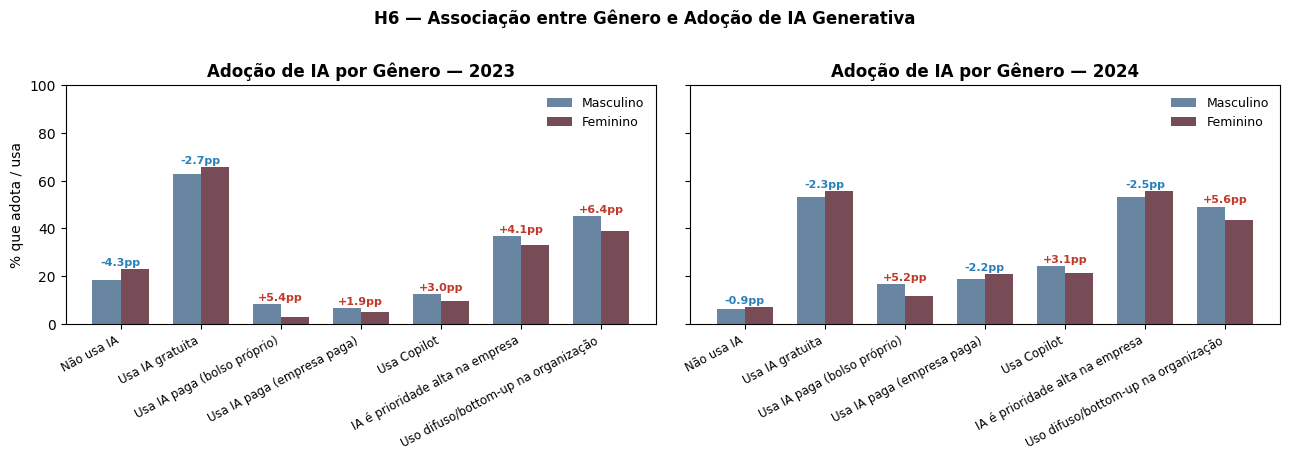

In [51]:
df_ia = df[df['ano_pesquisa'].isin(['2023', '2024'])].copy()

def chi2_cramer_ia(df_sub, feat, ano_label):
    sub = df_sub.dropna(subset=[feat, 'genero'])
    if sub['genero'].nunique() < 2:
        return None
    ct = pd.crosstab(sub['genero'], sub[feat])
    if ct.shape[1] < 2:
        return None

    chi2, p, _, _ = chi2_contingency(ct, correction=False)
    n = ct.values.sum()
    v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

    def _pct_ic(index_label):
        if index_label not in ct.index:
            return np.nan, (np.nan, np.nan)
        row   = ct.loc[index_label]
        n_usa = int(row.get(1, 0))
        n_tot = int(row.sum())
        return (n_usa / n_tot * 100 if n_tot > 0 else np.nan,
                wilson_ic(n_usa, n_tot))

    pct_m, ic_m = _pct_ic('Masculino')
    pct_f, ic_f = _pct_ic('Feminino')

    return {
        'Ano':             ano_label,
        'Feature':         IA_FEATURE_LABELS.get(feat, feat),
        '% Masculino':     round(pct_m, 1),
        'IC 95% Masc':     f'[{ic_m[0]:.3f}, {ic_m[1]:.3f}]',
        '% Feminino':      round(pct_f, 1),
        'IC 95% Fem':      f'[{ic_f[0]:.3f}, {ic_f[1]:.3f}]',
        'Gap (M−F) pp':    round(pct_m - pct_f, 1),
        'χ²':              round(chi2, 3),
        'p-valor':         round(p, 6),
        'V de Cramér':     round(v, 4),
        'Sig.':            ('***' if p < 0.001 else '**' if p < 0.01
                            else '*' if p < 0.05 else 'n.s.'),
    }


rows_h6 = []
for ano in ['2023', '2024']:
    sub_ano = df_ia[df_ia['ano_pesquisa'] == ano]
    for feat in IA_FEATURES_MODELO_B:
        r = chi2_cramer_ia(sub_ano, feat, ano)
        if r:
            rows_h6.append(r)

for feat in IA_FEATURES_MODELO_B:
    r = chi2_cramer_ia(df_ia, feat, '2023–2024')
    if r:
        rows_h6.append(r)

df_h6 = pd.DataFrame(rows_h6)

for ano in ['2023', '2024', '2023–2024']:
    print(f'\n── H6 — {ano} ──')
    print(df_h6[df_h6['Ano'] == ano].to_string(index=False))

# Gráfico H6
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, ano in zip(axes, ['2023', '2024']):
    sub = df_h6[df_h6['Ano'] == ano].set_index('Feature')
    x   = np.arange(len(sub))
    w   = 0.35
    ax.bar(x - w/2, sub['% Masculino'], w, color='#517493', alpha=0.87, label='Masculino')
    ax.bar(x + w/2, sub['% Feminino'],  w, color='#64313E', alpha=0.87, label='Feminino')
    for xi, (vm, vf) in enumerate(zip(sub['% Masculino'], sub['% Feminino'])):
        gap = vm - vf
        cor = '#C0392B' if gap > 0 else '#2980B9'
        ax.text(xi, max(vm, vf) + 1.5, f'{gap:+.1f}pp',
                ha='center', fontsize=8, color=cor, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(sub.index, rotation=28, ha='right', fontsize=8.5)
    ax.set_ylabel('% que adota / usa' if ano == '2023' else '')
    ax.set_ylim(0, 100)
    ax.set_title(f'Adoção de IA por Gênero — {ano}', fontweight='bold')
    ax.legend(frameon=False, fontsize=9)

plt.suptitle('H6 — Associação entre Gênero e Adoção de IA Generativa',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/3_6_h6_ia_genero.png', dpi=150, bbox_inches='tight')
plt.show()


In [52]:
resultados = {}
resultados['H1_H2_Chi2']         = tab_chi2
resultados['H3_MannWhitney']     = tab_mw
resultados['H4a_Spearman_Nivel'] = tab_sp_nivel_sal
resultados['H4b_Spearman_Exp']   = tab_sp_exp_sal
resultados['H5_Temporal']        = tab_temp
resultados['H6_IA_Genero']       = df_h6
 
with pd.ExcelWriter('resultados_estatisticos.xlsx') as writer:
    tab_chi2.to_excel(writer,          sheet_name='H1-H2 Chi2 Cramer')
    tab_mw.to_excel(writer,            sheet_name='H3 Mann-Whitney')
    tab_sp_nivel_sal.to_excel(writer,  sheet_name='H4a Spearman Nivel')
    if not tab_sp_exp_sal.empty:
        tab_sp_exp_sal.to_excel(writer, sheet_name='H4b Spearman Exp')
    tab_temp.to_excel(writer,          sheet_name='H5 Tendencia Temporal')
    df_h6.to_excel(writer,             sheet_name='H6 IA Genero', index=False)
 
print('resultados_estatisticos.xlsx salvo')

resultados_estatisticos.xlsx salvo


---
## Seção 4 — Modelagem Preditiva (Machine Learning)



In [53]:
BASE_FEATURES = [
    'nivel_ensino', 'area_formacao', 'cargo',
    'tempo_area_dados', 'tempo_area_ti', 'modalidade',
    'setor', 'regiao', 'situacao',
]
TARGETS = {
    'faixa_salarial': 'multiclass',
    'nivel':          'multiclass',
    'gestor':         'binario',
}
TARGET_LABELS = {
    'faixa_salarial': 'Faixa Salarial',
    'nivel':          'Senioridade',
    'gestor':         'Gestor/a',
}
ORDEM_MAP = {
    'faixa_salarial': FAIXA_SALARIAL_ORDEM,
    'nivel':          NIVEL_SENIORIDADE_ORDEM,
}

In [54]:
def prepare_xy(df, target, extra_features=None):
    exclude = {'gestor': ['nivel', 'cargo']}
    feats = [f for f in BASE_FEATURES if f not in exclude.get(target, [])]
    if extra_features:
        feats += [f for f in extra_features if f in df.columns]

    sub = df[feats + [target, 'genero', 'ano_pesquisa']].copy()

    codes = pd.Categorical(
        sub['nivel_ensino'], categories=NIVEL_ENSINO_ORDEM, ordered=True
    ).codes.astype(float)
    codes[codes == -1] = np.nan
    sub['nivel_ensino'] = codes

    if target == 'gestor':
        sub['y'] = pd.to_numeric(sub[target], errors='coerce')
    else:
        codes = pd.Categorical(
            sub[target], categories=ORDEM_MAP[target], ordered=True
        ).codes.astype(float)
        codes[codes == -1] = np.nan
        sub['y'] = codes

    sub = sub.dropna(subset=['y'])
    return sub[feats].copy(), sub['y'].astype(int), sub[['genero', 'ano_pesquisa']].copy()

In [55]:
def build_preprocessor(X):
    num_cols = X.select_dtypes(include='number').columns.tolist()
    cat_cols = X.select_dtypes(exclude='number').columns.tolist()
    steps = []
    if num_cols:
        steps.append(('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('scl', StandardScaler())]), num_cols))
    if cat_cols:
        steps.append(('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols))
    return ColumnTransformer(steps, remainder='drop')


def get_models(task_type):
    kw = dict(random_state=SEED)
    binary = task_type == 'binario'
    return {
        'Logistic Regression': LogisticRegression(max_iter=500, class_weight='balanced', **kw),
        'Random Forest':       RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, **kw),
        'XGBoost':             XGBClassifier(n_estimators=200, verbosity=0, **kw,
                                   eval_metric='logloss' if binary else 'mlogloss',
                                   **(dict(scale_pos_weight=5) if binary else {})),
    }

In [56]:
def run_cv(X, y, task_type, cv=5):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=SEED)
    rows = []
    for name, model in get_models(task_type).items():
        scores = cross_val_score(Pipeline([('pre', build_preprocessor(X)), ('clf', model)]),
                                 X, y, cv=skf, scoring='f1_macro', n_jobs=-1)
        rows.append({'Modelo': name, 'F1_mean': scores.mean(), 'F1_std': scores.std()})
        print(f'    {name:22s}: {scores.mean():.3f} ± {scores.std():.3f}')
    return pd.DataFrame(rows)


def treinar_avaliar(target, task_type, df_train, df_test, extra_features=None, label_extra=''):
    tag = TARGET_LABELS[target] + (f' {label_extra}' if label_extra else '')
    print(f'\n{"="*55}\n  {tag}\n{"="*55}')

    X_tr, y_tr, _    = prepare_xy(df_train, target, extra_features)
    X_te, y_te, meta = prepare_xy(df_test,  target, extra_features)
    print(f'  Treino: {len(X_tr):,} | Teste: {len(X_te):,} | Classes: {sorted(y_tr.unique())}')

    cv_df     = run_cv(X_tr, y_tr, task_type)
    best_name = cv_df.loc[cv_df['F1_mean'].idxmax(), 'Modelo']
    print(f'  → {best_name}')

    pipe = Pipeline([('pre', build_preprocessor(X_tr)), ('clf', get_models(task_type)[best_name])])
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)

    print(classification_report(y_te, y_pred, zero_division=0))

    rows = [{'Gênero': g, 'N': int((m := meta['genero'] == g).sum()),
             'F1_macro': round(f1_score(y_te[m], y_pred[m], average='macro', zero_division=0), 4)}
            for g in ['Masculino', 'Feminino'] if (meta['genero'] == g).any()]
    print(pd.DataFrame(rows).to_string(index=False))

    return dict(target=target, label=tag, best_name=best_name, pipe=pipe,
                X_tr=X_tr, X_te=X_te, y_te=y_te, y_pred=y_pred, meta=meta)

In [57]:
df_train = pd.read_parquet('data/df_train.parquet')
df_test  = pd.read_parquet('data/df_test.parquet')

print(f'df_train: {len(df_train):,} linhas — anos {sorted(df_train["ano_pesquisa"].unique())}')
print(f'df_test:  {len(df_test):,} linhas — anos {sorted(df_test["ano_pesquisa"].unique())}')

ia_treino = [c for c in IA_FEATS_ALL if c in df_train.columns and df_train[c].notna().any()]
ia_teste  = [c for c in IA_FEATS_ALL if c in df_test.columns  and df_test[c].notna().any()]

def cobertura(df, cols):
    return df[cols].notna().any(axis=1).mean() * 100 if cols else 0.0

print(f'\nIA treino: {len(ia_treino)}/{len(IA_FEATS_ALL)} features — {cobertura(df_train, ia_treino):.1f}% das linhas')
print(f'IA teste:  {len(ia_teste)}/{len(IA_FEATS_ALL)} features — {cobertura(df_test,  ia_teste):.1f}% das linhas')

df_train: 12,117 linhas — anos ['2021', '2022', '2023']
df_test:  5,178 linhas — anos ['2024']

IA treino: 5/5 features — 38.3% das linhas
IA teste:  5/5 features — 89.5% das linhas


In [58]:
results_A = {}
for target, task_type in TARGETS.items():
    results_A[target] = treinar_avaliar(
        target, task_type, df_train, df_test, label_extra='[A]',
    )


  Faixa Salarial [A]
  Treino: 10,643 | Teste: 4,795 | Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
    Logistic Regression   : 0.262 ± 0.007
    Random Forest         : 0.266 ± 0.015
    XGBoost               : 0.262 ± 0.010
  → Random Forest
              precision    recall  f1-score   support

           0       0.52      0.68      0.59       151
           1       0.27      0.26      0.26       235
           2       0.17      0.15      0.16       268
           3       0.30      0.33      0.31       592
           4       0.23      0.18      0.20       649
           5       0.36      0.49      0.41      1070
           6       0.29      0.33      0.31       714
           7       0.26      0.16      0.20       453
           8       0.17      0.12      0.14       246
           9       0.18      0.11      0.13       159
          10       0.22      0.12    

In [59]:
results_B = {}
for target, task_type in TARGETS.items():
    results_B[target] = treinar_avaliar(
        target, task_type, df_train, df_test,
        extra_features=IA_FEATURES_MODELO_B, label_extra='[B]',
    )


  Faixa Salarial [B]
  Treino: 10,643 | Teste: 4,795 | Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
    Logistic Regression   : 0.260 ± 0.007
    Random Forest         : 0.264 ± 0.015
    XGBoost               : 0.264 ± 0.010
  → Random Forest
              precision    recall  f1-score   support

           0       0.52      0.67      0.58       151
           1       0.29      0.26      0.27       235
           2       0.19      0.14      0.16       268
           3       0.32      0.37      0.34       592
           4       0.25      0.15      0.19       649
           5       0.36      0.54      0.43      1070
           6       0.28      0.33      0.31       714
           7       0.24      0.14      0.18       453
           8       0.21      0.14      0.17       246
           9       0.19      0.12      0.15       159
          10       0.28      0.14    

---
## Seção 5 — Explicabilidade com SHAP

In [60]:
def compute_shap(pipe, X, model_name, max_samples=300):
    pre = pipe.named_steps['pre']
    clf = pipe.named_steps['clf']

    idx = np.random.RandomState(SEED).choice(len(X), min(max_samples, len(X)), replace=False)
    X_s = X.iloc[idx]
    X_t = pre.transform(X_s)

    try:
        feat_names = np.array(pre.get_feature_names_out())
    except Exception:
        feat_names = np.array([f'f{i}' for i in range(X_t.shape[1])])

    if 'XGBoost' in model_name or 'Random Forest' in model_name:
        sv = shap.TreeExplainer(
            clf, feature_perturbation='tree_path_dependent'
        ).shap_values(X_t, check_additivity=False)
    else:
        sv = shap.LinearExplainer(
            clf, shap.maskers.Independent(X_t)
        ).shap_values(X_t)

    if isinstance(sv, list):
        # multiclasse: média dos absolutos entre classes
        mean_abs = np.mean([np.abs(s) for s in sv], axis=0).mean(axis=0)
    else:
        sv = np.array(sv)
        if sv.ndim == 3:
            # XGBoost binário às vezes retorna (n, features, 2)
            sv = sv[:, :, 1]
        mean_abs = np.abs(sv).mean(axis=0)

    # normaliza para soma = 1 — comparação entre modelos fica proporcional
    total = mean_abs.sum()
    if total > 0:
        mean_abs = mean_abs / total

    return mean_abs, feat_names

In [ ]:
shap_cache = {}
for target in TARGETS:
    safe = target.replace(' ', '_')
    for key, results, hl in [('A', results_A, False), ('B', results_B, True)]:
        try:
            r = results[target]
            ms, fn = compute_shap(r['pipe'], r['X_te'], r['best_name'])
            shap_cache[f'{key}_{target}'] = (ms, fn)
            plot_shap_bar(ms, fn,
                title=f'SHAP — {TARGET_LABELS[target]} · Modelo {key} ({r["best_name"]})',
                fname=f'shap_{key}_{safe}.png', highlight_ia=hl)
        except Exception as e:
            print(f' SHAP Modelo {key} / {target}: {e}')

 SHAP Modelo A / faixa_salarial: name 'plot_shap_bar' is not defined


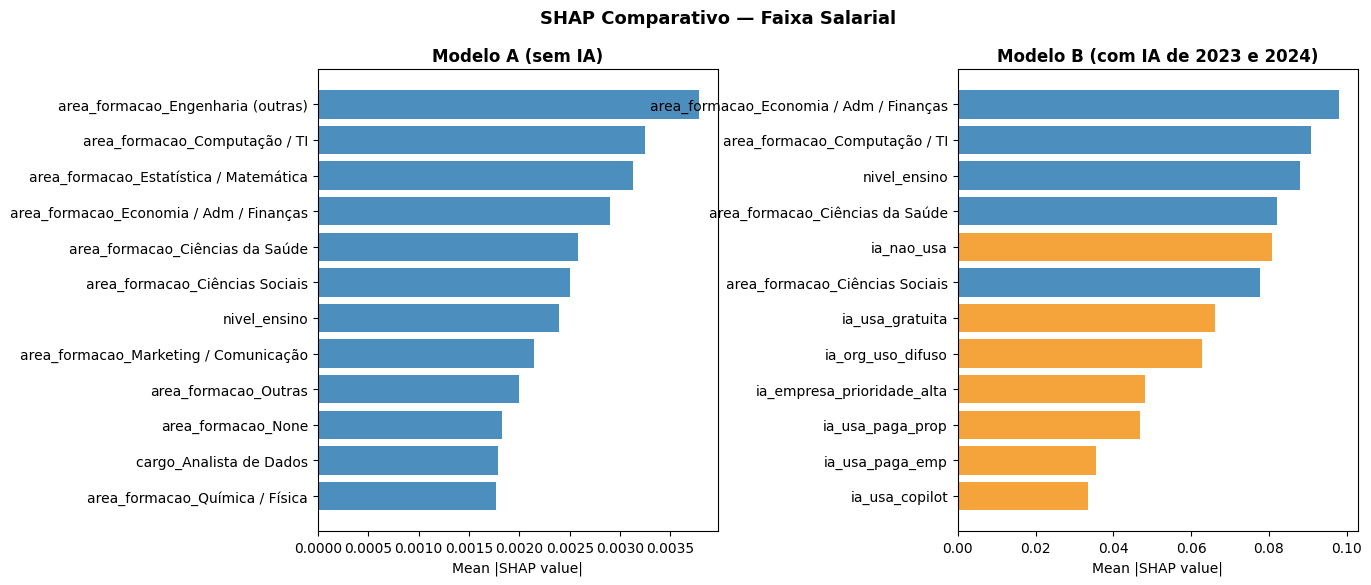

   figures/shap_comp_faixa_salarial.png


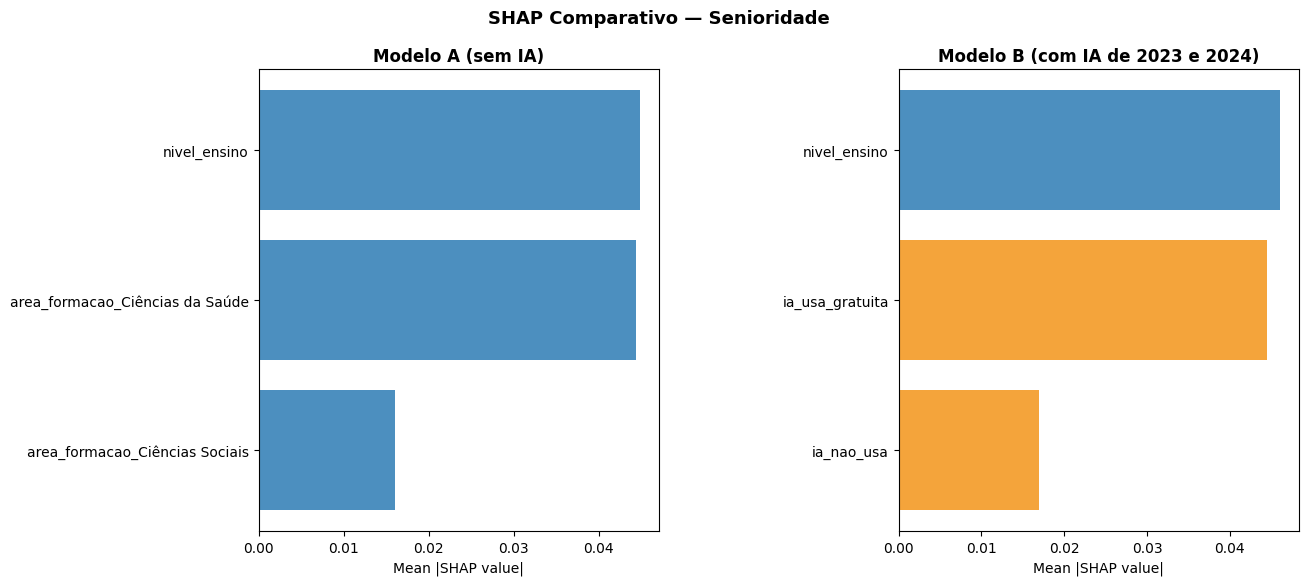

   figures/shap_comp_nivel.png


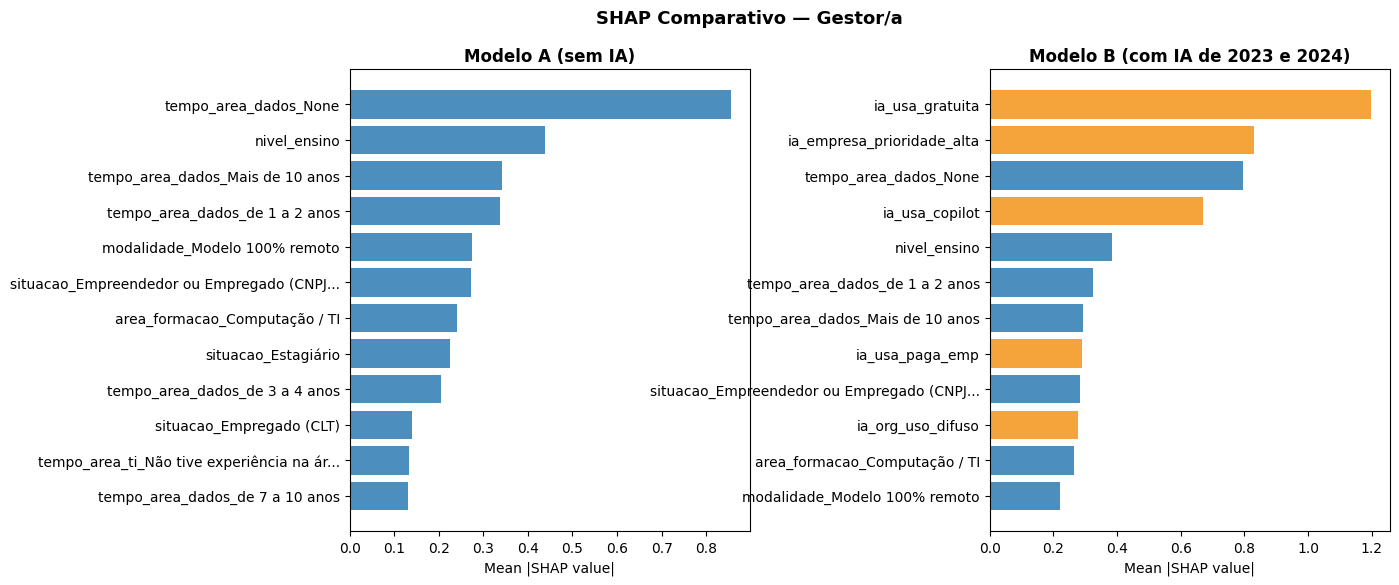

   figures/shap_comp_gestor.png


In [ ]:
def clean_feat_name(name: str, max_len: int = 40) -> str:
    name = name.replace('cat__', '').replace('num__', '')
    return name[:max_len] + '...' if len(name) > max_len else name

def is_ia_feature(name: str) -> bool:
    return 'ia_' in name

def plot_shap_bar(mean_shap, feat_names, top_n=15, title='SHAP', fname='shap.png', highlight_ia=False):
    top_idx = np.argsort(mean_shap)[::-1][:top_n]
    names_r = feat_names[top_idx]
    vals    = mean_shap[top_idx]
    names_c = [clean_feat_name(n) for n in names_r]
    colors  = ['#F4A43B' if is_ia_feature(n) else '#4C8FBF' for n in names_r] if highlight_ia else ['#4C8FBF'] * len(names_r)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(names_c[::-1], vals[::-1], color=colors[::-1])
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title(title, fontweight='bold', loc='left')
    fig.subplots_adjust(left=0.35)
    if highlight_ia:
        ax.legend(handles=[
            mpatches.Patch(color='#F4A43B', label='Feature de IA generativa'),
            mpatches.Patch(color='#4C8FBF', label='Feature base'),
        ], loc='lower right', frameon=False)
    plt.savefig(f'figures/{fname}', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'   figures/{fname}')


def plot_shap_comparacao(target, top_n=12):
    key_a, key_b = f'A_{target}', f'B_{target}'
    if key_a not in shap_cache or key_b not in shap_cache:
        print(f'⚠️ SHAP não disponível para {target}'); return

    def top(ms, fn, n):
        idx = np.argsort(ms)[::-1][:n]
        return [clean_feat_name(fn[i]) for i in idx], ms[idx]

    ms_a, fn_a = shap_cache[key_a]
    ms_b, fn_b = shap_cache[key_b]
    names_a, vals_a = top(ms_a, fn_a, top_n)
    names_b, vals_b = top(ms_b, fn_b, top_n)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, names, vals, subtitle, hl in [
        (axes[0], names_a, vals_a, 'Modelo A (sem IA)', False),
        (axes[1], names_b, vals_b, 'Modelo B (com IA de 2023 e 2024)', True),
    ]:
        colors = ['#F4A43B' if 'ia_' in n else '#4C8FBF' for n in names] if hl else ['#4C8FBF'] * len(names)
        ax.barh(names[::-1], vals[::-1], color=colors[::-1])
        ax.set_xlabel('Mean |SHAP value|')
        ax.set_title(subtitle, fontweight='bold')

    fig.suptitle(f'SHAP Comparativo — {TARGET_LABELS[target]}', fontsize=13, fontweight='bold')
    fig.subplots_adjust(left=0.25, wspace=0.6)
    plt.savefig(f'figures/shap_comp_{target}.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'   figures/shap_comp_{target}.png')


for target in TARGETS:
    plot_shap_comparacao(target)